# World Cup

In [49]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download(
    "nalisha/fifa-world-cup-2022-match-performance-dataset"
)

print("Path to dataset files:", path)

Path to dataset files: C:\Users\yarah\.cache\kagglehub\datasets\nalisha\fifa-world-cup-2022-match-performance-dataset\versions\1


### Undertsanding the data

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import requests
from PIL import Image
from io import BytesIO

In [47]:
data = pd.read_csv(path + "/Fifa_world_cup_matches.csv")
print(data.head())

           team1         team2 possession team1 possession team2  \
0          QATAR       ECUADOR              42%              50%   
1        ENGLAND          IRAN              72%              19%   
2        SENEGAL   NETHERLANDS              44%              45%   
3  UNITED STATES         WALES              51%              39%   
4      ARGENTINA  SAUDI ARABIA              64%              24%   

  possession in contest  number of goals team1  number of goals team2  \
0                    8%                      0                      2   
1                    9%                      6                      2   
2                   11%                      0                      2   
3                   10%                      1                      1   
4                   12%                      1                      2   

          date     hour category  ...  penalties scored team1  \
0  20 NOV 2022  17 : 00  Group A  ...                       0   
1  21 NOV 2022  14 : 0

In [8]:
!pip install Pillow requests


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


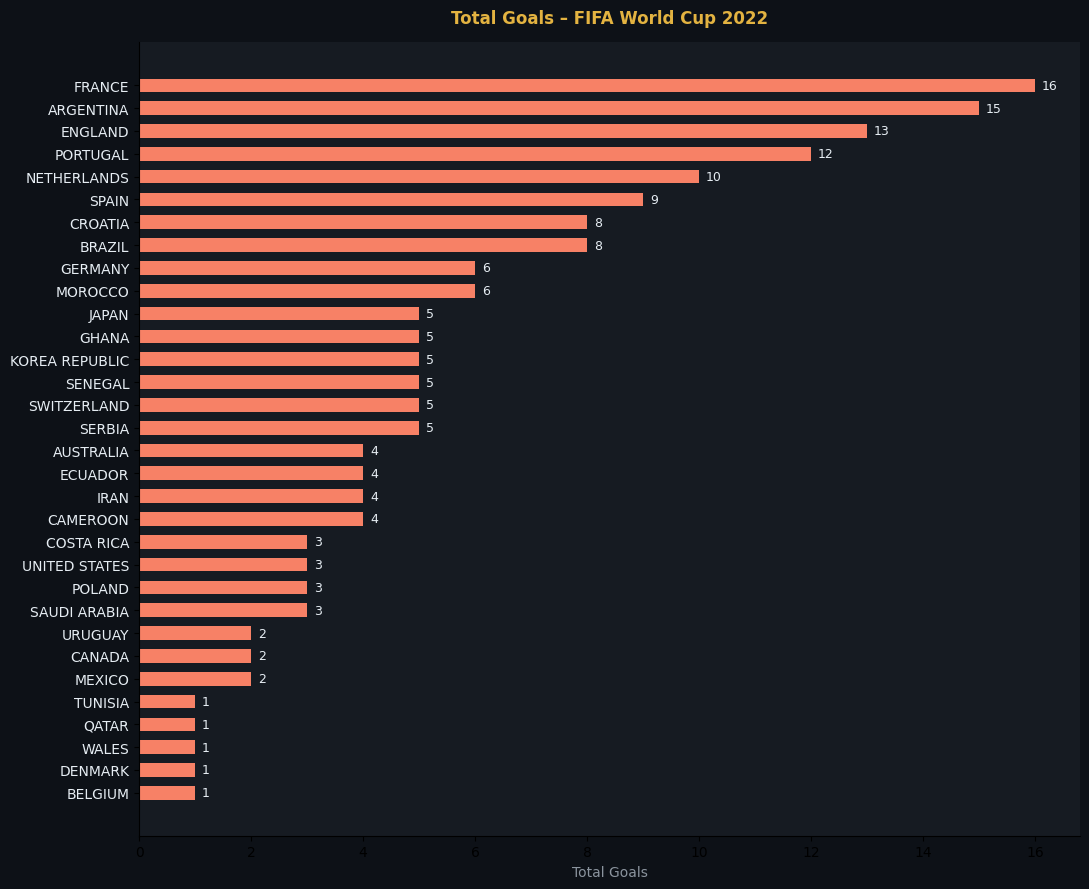

In [34]:
def plot_goals(df):
    # --- aggregate goals per team
    goals = (
        pd.concat(
            [
                df[["team1", "number of goals team1"]].rename(
                    columns={"team1": "team", "number of goals team1": "goals"}
                ),
                df[["team2", "number of goals team2"]].rename(
                    columns={"team2": "team", "number of goals team2": "goals"}
                ),
            ]
        )
        .groupby("team")["goals"]
        .sum()
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(11, 9))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#161b22")

    # --- draw bars
    bars = ax.barh(
        range(len(goals)), goals.values, color="#f78166", height=0.6, edgecolor="none"
    )
    ax.bar_label(bars, padding=5, color="#e6edf3", fontsize=9)

    ax.set_yticks(range(len(goals)))
    ax.set_yticklabels(goals.index, color="#e6edf3", fontsize=10)
    ax.set_xlabel("Total Goals", color="#8b949e")
    ax.set_title(
            "Total Goals – FIFA World Cup 2022",
            color="#e3b341",
            fontweight="bold",
            pad=14,
        )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.savefig(
        "goals_with_flags.png",
        dpi=150,
        bbox_inches="tight",
        facecolor=fig.get_facecolor(),
    )
    plt.show()


plot_goals_with_flags(data)

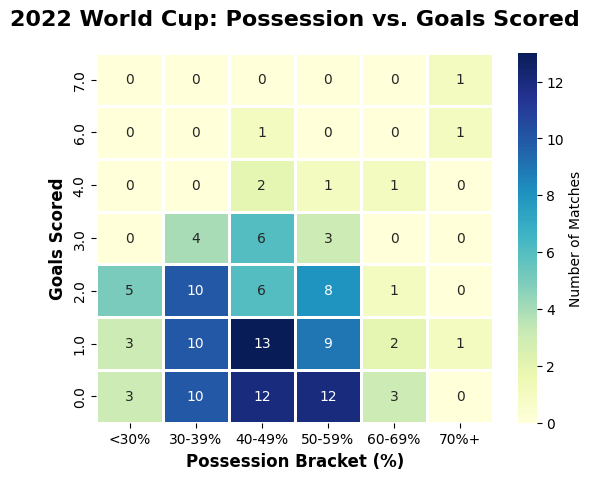

Correlation coefficient between possession and goals scored: 0.13


In [76]:
# To find possession vs. goals scored
team1 = data[["team1", "possession team1", "number of goals team1", "number of goals team2"]].copy()
team1.columns = ["team", "possession", "goals_scored", "goals_conceded"]

team2 = data[["team2", "possession team2", "number of goals team2", "number of goals team1"]].copy()
team2.columns = ["team", "possession", "goals_scored", "goals_conceded"]

matches = pd.concat([team1, team2], ignore_index=True)
matches["possession"] = matches["possession"].str.replace("%", "").astype(float)
matches["goals_scored"] = matches["goals_scored"].astype(float)

# Determine match outcome for each row
def get_outcome(row):
    if row["goals_scored"] > row["goals_conceded"]:
        return "Win"
    elif row["goals_scored"] < row["goals_conceded"]:
        return "Loss"
    else:
        return "Draw"

matches["outcome"] = matches.apply(get_outcome, axis=1)

correlation_coefficient = matches["possession"].corr(matches["goals_scored"])

bin_edges = [0, 30, 40, 50, 60, 70, 100]
bin_labels = ['<30%', '30-39%', '40-49%', '50-59%', '60-69%', '70%+']
matches['possession_Bin'] = pd.cut(matches['possession'], bins=bin_edges, labels=bin_labels, right=False)
heatmap_data = pd.crosstab(index=matches['goals_scored'], columns=matches['possession_Bin'])

# 3. Sort the index so higher goals appear at the top of the Y-axis
heatmap_data = heatmap_data.sort_index(ascending=False)

# 4. Strip the Categorical metadata from the columns so Seaborn doesn't crash
heatmap_data.columns = heatmap_data.columns.astype(str)

# --- THE FIX ENDS HERE ---

# Now the heatmap will plot perfectly
sns.heatmap(heatmap_data, 
            annot=True, 
            fmt="d",  # "d" works perfectly now because crosstab outputs integer counts
            cmap="YlGnBu", 
            linewidths=1, 
            linecolor='white',
            cbar_kws={'label': 'Number of Matches'})

plt.title('2022 World Cup: Possession vs. Goals Scored', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Possession Bracket (%)', fontsize=12, fontweight='bold')
plt.ylabel('Goals Scored', fontsize=12, fontweight='bold')

plt.show()

print(f"Correlation coefficient between possession and goals scored: {correlation_coefficient:.2f}")

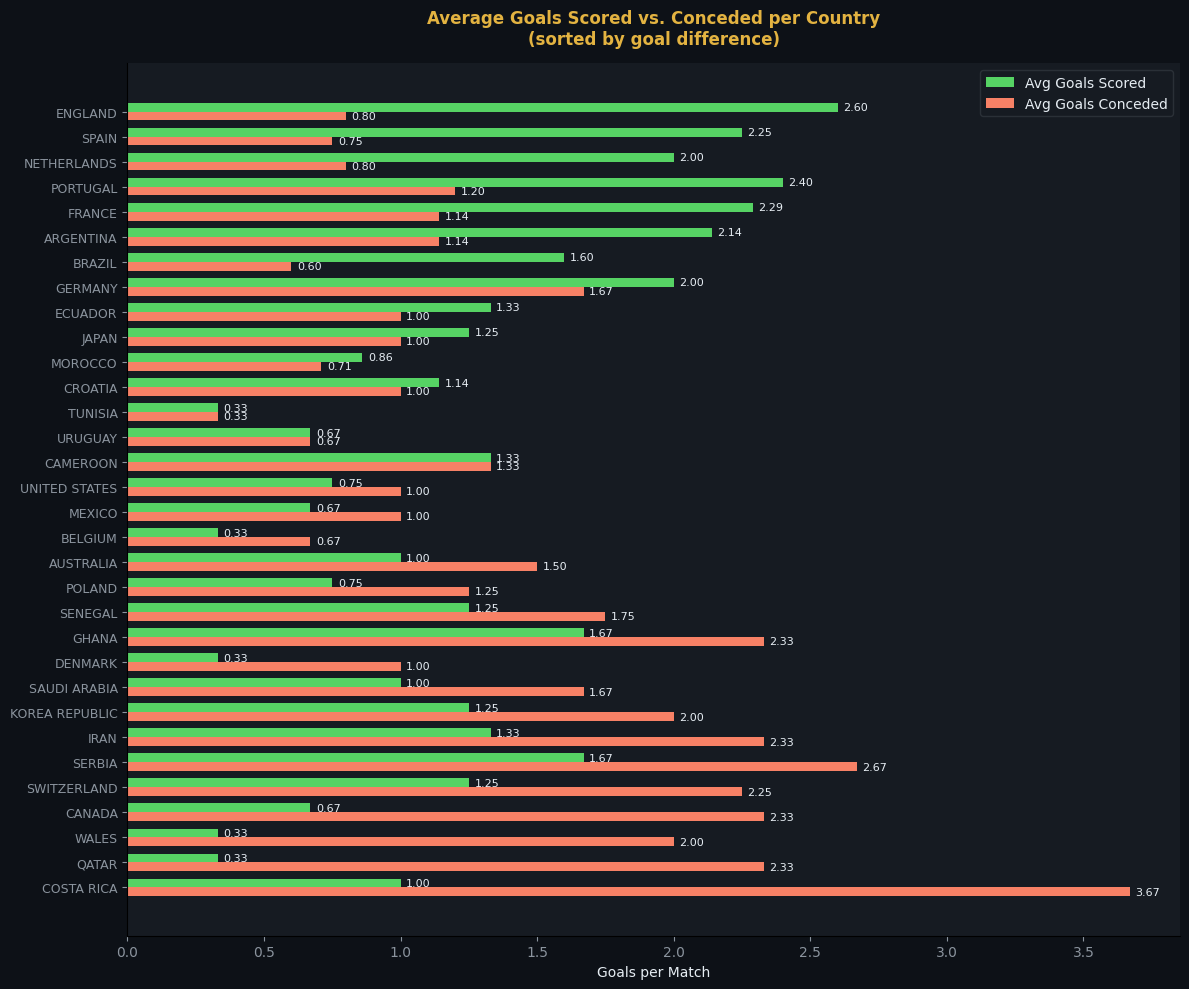

In [55]:
# --- Build combined dataframe same as before
team1 = data[["team1", "number of goals team1", "number of goals team2"]].copy()
team1.columns = ["team", "goals_scored", "goals_conceded"]

team2 = data[["team2", "number of goals team2", "number of goals team1"]].copy()
team2.columns = ["team", "goals_scored", "goals_conceded"]

matches = pd.concat([team1, team2], ignore_index=True)

# --- Average stats per country
avg = matches.groupby("team").agg(
    avg_scored=("goals_scored", "mean"),
    avg_conceded=("goals_conceded", "mean"),
).round(2)
avg["goal_diff"] = avg["avg_scored"] - avg["avg_conceded"]
avg = avg.sort_values("goal_diff", ascending=True)  # sort by goal difference

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor("#0d1117")
ax.set_facecolor("#161b22")

y = np.arange(len(avg))
height = 0.35

bars1 = ax.barh(y + height/2, avg["avg_scored"],   height=height, color="#56d364", label="Avg Goals Scored",   edgecolor="none")
bars2 = ax.barh(y - height/2, avg["avg_conceded"], height=height, color="#f78166", label="Avg Goals Conceded", edgecolor="none")

# Value labels
ax.bar_label(bars1, padding=4, fmt="%.2f", color="#e6edf3", fontsize=8)
ax.bar_label(bars2, padding=4, fmt="%.2f", color="#e6edf3", fontsize=8)

# --- Formatting
ax.set_yticks(y)
ax.set_yticklabels(avg.index, color="#e6edf3", fontsize=9)
ax.set_xlabel("Goals per Match", color="#e6edf3")
ax.set_title("Average Goals Scored vs. Conceded per Country\n(sorted by goal difference)",
             color="#e3b341", fontweight="bold", pad=14)
ax.legend(facecolor="#161b22", edgecolor="#30363d", labelcolor="#e6edf3")
ax.tick_params(colors="#8b949e")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("avg_goals_per_country.png", dpi=150, bbox_inches="tight")
plt.show()

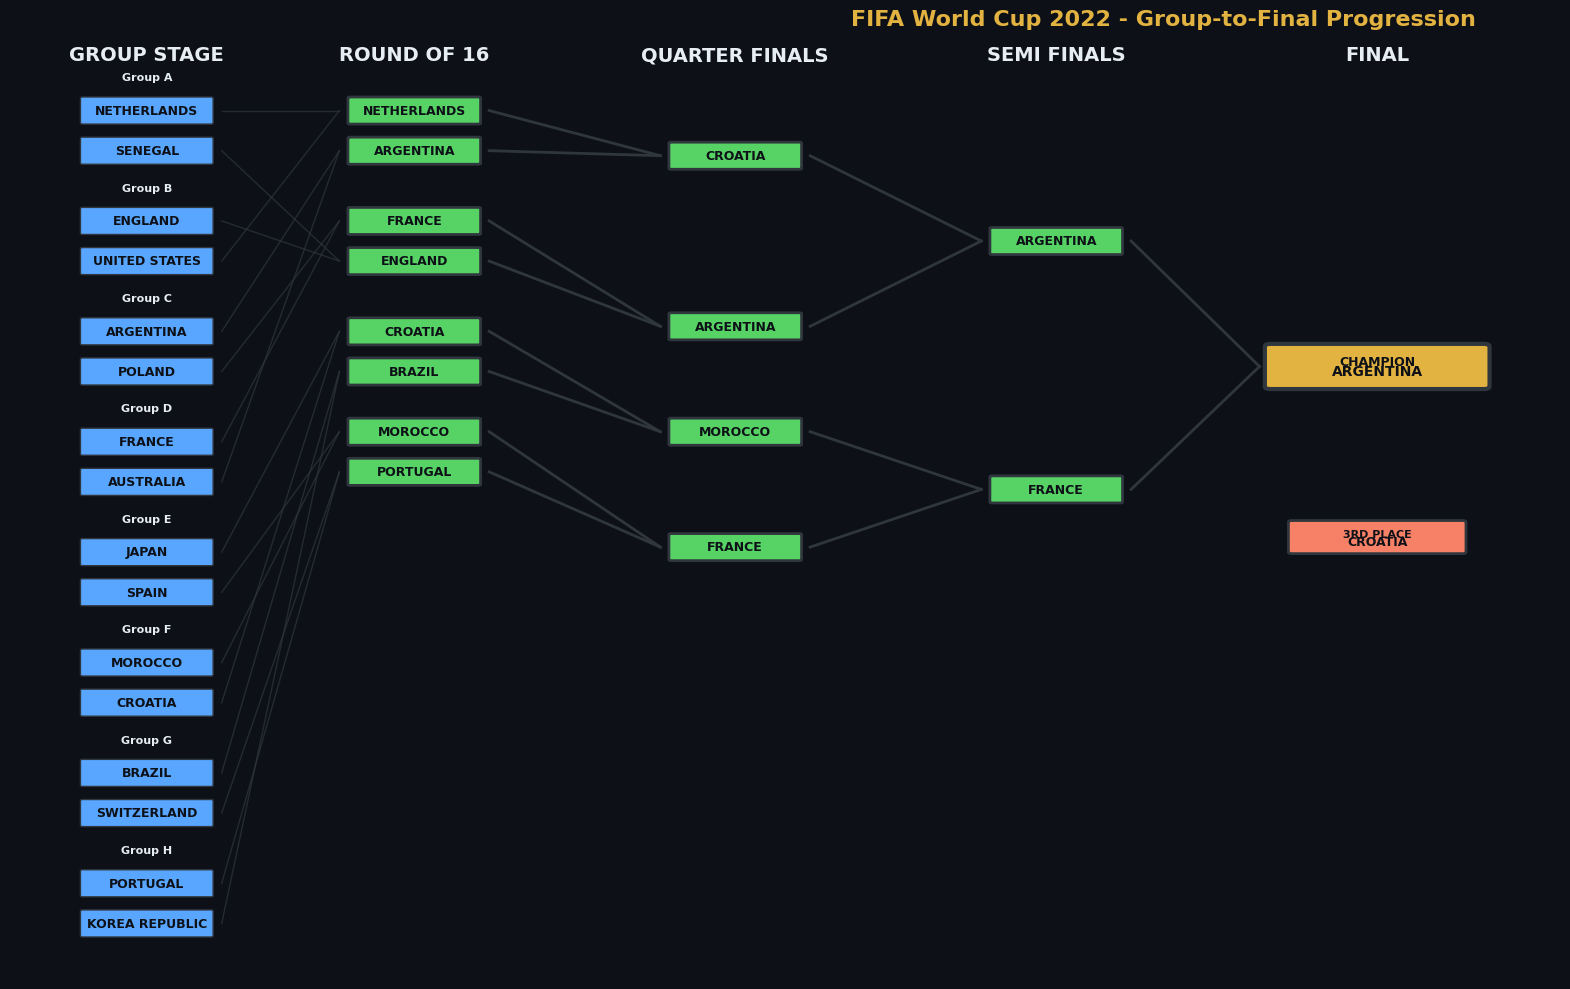

In [56]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np

stage_order = [
    "Round of 16",
    "Quarter-final",
    "Semi-final",
    "Final"
]

shootout_winners = {
    ("Final", "ARGENTINA", "FRANCE"): "ARGENTINA",
}


def compute_group_advancers(df):
    groups = sorted(df[df["category"].str.contains("Group")]["category"].unique())
    advancers = {}

    for group in groups:
        group_df = df[df["category"] == group]

        team1 = group_df[["team1", "number of goals team1", "number of goals team2"]].copy()
        team1.columns = ["team", "scored", "conceded"]
        team2 = group_df[["team2", "number of goals team2", "number of goals team1"]].copy()
        team2.columns = ["team", "scored", "conceded"]

        all_teams = pd.concat([team1, team2], ignore_index=True)
        stats = all_teams.groupby("team").agg(
            scored=("scored", "sum"),
            conceded=("conceded", "sum"),
        ).reset_index()
        stats["goal_diff"] = stats["scored"] - stats["conceded"]
        stats["points"] = 0

        for _, row in group_df.iterrows():
            if row["number of goals team1"] > row["number of goals team2"]:
                stats.loc[stats["team"] == row["team1"], "points"] += 3
            elif row["number of goals team1"] < row["number of goals team2"]:
                stats.loc[stats["team"] == row["team2"], "points"] += 3
            else:
                stats.loc[stats["team"] == row["team1"], "points"] += 1
                stats.loc[stats["team"] == row["team2"], "points"] += 1

        stats = stats.sort_values(
            ["points", "goal_diff", "scored", "team"],
            ascending=[False, False, False, True],
        )
        advancers[group] = stats["team"].tolist()[:2]

    return advancers


def get_match_winner(row, next_stage_teams=None):
    team1 = row["team1"]
    team2 = row["team2"]
    score1 = float(row["number of goals team1"])
    score2 = float(row["number of goals team2"])

    if score1 > score2:
        return team1
    if score2 > score1:
        return team2

    if next_stage_teams is not None:
        if team1 in next_stage_teams and team2 not in next_stage_teams:
            return team1
        if team2 in next_stage_teams and team1 not in next_stage_teams:
            return team2

    key = (row["category"], team1, team2)
    if key in shootout_winners:
        return shootout_winners[key]

    key_reversed = (row["category"], team2, team1)
    if key_reversed in shootout_winners:
        return shootout_winners[key_reversed]

    return team1


def build_knockout_progression(df):
    matches = {stage: df[df["category"] == stage].copy().reset_index(drop=True) for stage in stage_order}
    progression = {}

    for i, stage in enumerate(stage_order):
        next_stage_teams = None
        if i + 1 < len(stage_order):
            next_stage_df = matches[stage_order[i + 1]]
            next_stage_teams = set(next_stage_df["team1"].tolist() + next_stage_df["team2"].tolist())

        progression[stage] = []
        for _, row in matches[stage].iterrows():
            progression[stage].append(
                {
                    "team1": row["team1"],
                    "team2": row["team2"],
                    "winner": get_match_winner(row, next_stage_teams),
                }
            )

    progression["Play-off for third place"] = []
    third_df = df[df["category"] == "Play-off for third place"].copy().reset_index(drop=True)
    for _, row in third_df.iterrows():
        progression["Play-off for third place"].append(
            {
                "team1": row["team1"],
                "team2": row["team2"],
                "winner": get_match_winner(row),
            }
        )

    return progression


def plot_bracket(df):
    group_advancers = compute_group_advancers(df)
    progression = build_knockout_progression(df)
    r16_matches = progression["Round of 16"]
    qf_matches = progression["Quarter-final"]
    sf_matches = progression["Semi-final"]
    final_match = progression["Final"][0]
    third_match = progression["Play-off for third place"][0]

    fig, ax = plt.subplots(figsize=(20, 12))
    fig.patch.set_facecolor("#0d1117")
    ax.set_facecolor("#0d1117")
    ax.axis("off")

    group_positions = {}
    y_base = 10.5
    for group, teams in group_advancers.items():
        group_positions[group] = {}
        for idx, team in enumerate(teams):
            x = 0.5
            y = y_base - idx * 0.8
            box = FancyBboxPatch((x - 0.6, y - 0.25), 1.2, 0.5,
                                 boxstyle="round,pad=0.02",
                                 facecolor="#58a6ff", edgecolor="#30363d", linewidth=1)
            ax.add_patch(box)
            ax.text(x, y, team, ha="center", va="center",
                    fontsize=9, color="#0d1117", fontweight="bold")
            group_positions[group][team] = (x + 0.7, y)

        ax.text(0.5, y_base + 0.6, group, ha="center", fontsize=8,
                color="#e6edf3", fontweight="bold")
        y_base -= 2.2

    r16_positions = [
        (3, 10.5), (3, 9.7), (3, 8.3), (3, 7.5),
        (3, 6.1), (3, 5.3), (3, 4.1), (3, 3.3),
    ]

    for idx, match in enumerate(r16_matches):
        x, y = r16_positions[idx]
        box = FancyBboxPatch((x - 0.6, y - 0.25), 1.2, 0.5,
                             boxstyle="round,pad=0.02",
                             facecolor="#56d364", edgecolor="#30363d", linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, match["winner"], ha="center", va="center",
                fontsize=9, color="#0d1117", fontweight="bold")

        for team in [match["team1"], match["team2"]]:
            group_name = next((g for g, teams in group_advancers.items() if team in teams), None)
            if group_name is not None and team in group_positions[group_name]:
                sx, sy = group_positions[group_name][team]
                ax.plot([sx, x - 0.7], [sy, y], color="#30363d", linewidth=1, alpha=0.7)

    qf_positions = [
        (6, 9.6), (6, 6.2), (6, 4.1), (6, 1.8)
    ]
    for idx, match in enumerate(qf_matches):
        x, y = qf_positions[idx]
        box = FancyBboxPatch((x - 0.6, y - 0.25), 1.2, 0.5,
                             boxstyle="round,pad=0.02",
                             facecolor="#56d364", edgecolor="#30363d", linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, match["winner"], ha="center", va="center",
                fontsize=9, color="#0d1117", fontweight="bold")

        r16_a = r16_positions[idx * 2]
        r16_b = r16_positions[idx * 2 + 1]
        ax.plot([r16_a[0] + 0.7, x - 0.7], [r16_a[1], y], color="#30363d", linewidth=2)
        ax.plot([r16_b[0] + 0.7, x - 0.7], [r16_b[1], y], color="#30363d", linewidth=2)

    sf_positions = [(9, 7.9), (9, 2.95)]
    for idx, match in enumerate(sf_matches):
        x, y = sf_positions[idx]
        box = FancyBboxPatch((x - 0.6, y - 0.25), 1.2, 0.5,
                             boxstyle="round,pad=0.02",
                             facecolor="#56d364", edgecolor="#30363d", linewidth=2)
        ax.add_patch(box)
        ax.text(x, y, match["winner"], ha="center", va="center",
                fontsize=9, color="#0d1117", fontweight="bold")

        qf_a = qf_positions[idx * 2]
        qf_b = qf_positions[idx * 2 + 1]
        ax.plot([qf_a[0] + 0.7, x - 0.7], [qf_a[1], y], color="#30363d", linewidth=2)
        ax.plot([qf_b[0] + 0.7, x - 0.7], [qf_b[1], y], color="#30363d", linewidth=2)

    final_pos = (12, 5.4)
    box = FancyBboxPatch((final_pos[0] - 1, final_pos[1] - 0.4), 2, 0.8,
                         boxstyle="round,pad=0.05",
                         facecolor="#e3b341", edgecolor="#30363d", linewidth=3)
    ax.add_patch(box)
    ax.text(final_pos[0], final_pos[1] + 0.1, "CHAMPION",
            ha="center", va="center", fontsize=9, color="#0d1117", fontweight="bold")
    ax.text(final_pos[0], final_pos[1] - 0.1, final_match["winner"],
            ha="center", va="center", fontsize=10, color="#0d1117", fontweight="bold")

    ax.plot([sf_positions[0][0] + 0.7, final_pos[0] - 1.1], [sf_positions[0][1], final_pos[1]],
            color="#30363d", linewidth=2)
    ax.plot([sf_positions[1][0] + 0.7, final_pos[0] - 1.1], [sf_positions[1][1], final_pos[1]],
            color="#30363d", linewidth=2)

    third_pos = (12, 2)
    box = FancyBboxPatch((third_pos[0] - 0.8, third_pos[1] - 0.3), 1.6, 0.6,
                         boxstyle="round,pad=0.03",
                         facecolor="#f78166", edgecolor="#30363d", linewidth=2)
    ax.add_patch(box)
    ax.text(third_pos[0], third_pos[1] + 0.05, "3RD PLACE",
            ha="center", va="center", fontsize=8, color="#0d1117", fontweight="bold")
    ax.text(third_pos[0], third_pos[1] - 0.1, third_match["winner"],
            ha="center", va="center", fontsize=9, color="#0d1117", fontweight="bold")

    ax.text(0.5, 11.5, "GROUP STAGE", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")
    ax.text(3, 11.5, "ROUND OF 16", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")
    ax.text(6, 11.5, "QUARTER FINALS", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")
    ax.text(9, 11.5, "SEMI FINALS", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")
    ax.text(12, 11.5, "FINAL", ha="center", fontsize=14, color="#e6edf3", fontweight="bold")

    ax.text(10, 12.2, "FIFA World Cup 2022 - Group-to-Final Progression",
            ha="center", fontsize=16, color="#e3b341", fontweight="bold")

    # plt.tight_layout()
    plt.savefig("worldcup_progression_from_dataframe.png", dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()

plot_bracket(data)
